# 3W Dataset on Sensory data predicting Well Faults

# Variable information

* JUS = jusante = downstream
* MON = montante = upstream
* CKP = choke de produção = production choke
* CKGL = choke de gas lift = gas lift choke

1. Pressure at the Permanent Downhole Gauge — deep inside the well <strong>(P-PDG)</strong>;
2. Pressure at the Topside Pressure Transducer — at surface level <strong>(P-TPT)</strong>;
3. Temperature at the Topside Pressure Transducer <strong>T-TPT</strong>;
4. Pressure upstream of the Production Choke <strong>P-MON-CKP</strong>;
5. Temperature downstream of the Production Choke <strong>T-JUS-CKP</strong>;
6. Pressure downstream of the Gas Lift Choke <strong>P-JUS-CKGL</strong>;
7. Temperature downstream of the Gas Lift Choke <strong>T-JUS-CKGL</strong>;
8. Gas Lift Flow Rate — volume of gas being injected <strong>QGL</strong>;






### Understanding Basic Terms
An oil well is essentially a pipe going deep underground. Oil and gas are trapped in rock thousands of meters below. The challenge is getting it to the surface in a controlled way.

<hr>
Downhole Gauge (PDG)
A sensor sitting deep inside the well, close to where the oil actually is. It measures pressure at the source. Think of it as taking the pulse of the reservoir itself. "Downhole" just means underground, inside the well bore.

<hr>
Transducer (TPT)
A transducer is just a device that converts a physical property (like pressure or temperature) into an electrical signal you can record. TPT sits at the top of the well, at surface level. "Topside" means above ground. So P-PDG and P-TPT are both measuring pressure, just one is deep underground and one is at the surface.

<hr>
Production Choke (CKP)
Oil and gas coming up the well is under enormous pressure. You can't just let it blast out freely — it would be dangerous and uncontrollable. The production choke is essentially an adjustable valve that restricts the flow, controlling how fast oil comes out. Think of it like a tap. Measuring pressure before (upstream) and after (downstream) the choke tells you how much pressure is being lost across it, which reveals if something is wrong with flow.

<hr>
Gas Lift Choke (CKGL)
Sometimes a well doesn't have enough natural pressure to push oil to the surface on its own. Gas lift solves this by injecting gas down into the well, which lightens the column of fluid and helps push oil up — like blowing air into a straw submerged in water. The gas lift choke controls how much of that injected gas goes in. QGL is literally measuring how much gas is flowing through this choke.


## Purpose of model
The purpose of this models is to detect the possible occurence of faults in oil wells. 

The transient classes will be the most important classes in this dataset. The model detects faults before they occur, not to identify the fault after they occur. 

Target accuracy : > 0.97

##  Labels information

BSW (class 1) — water and sediment suddenly mixing into the oil flow. Bad for equipment and product quality.
<hr>
Incipient leak (class 2) — a small, developing leak in the production choke valve before it becomes a full rupture.
<hr>
Flow instability (class 3) — the flow oscillates unpredictably instead of being steady. Often caused by gas-liquid slugging.
<hr>
Rapid productivity loss (class 4) — the well suddenly starts producing much less oil, usually due to reservoir or damage issues.
<hr>
Quick restriction in choke (class 5) — something is partially blocking the production choke, reducing flow.
<hr>
Scaling (class 6) — mineral deposits building up inside the choke, slowly narrowing it.
Hydrate in production line (class 7) — ice-like crystals forming in the production pipe and blocking flow.
<hr>
Hydrate in service line (class 8) — same hydrate problem but in the service/gas lift line instead.

### Undertsanding classes

<strong>Class 0 — Normal Operation</strong>
The well is producing steadily. Reservoir pressure drives oil up through the wellbore, through the production choke, into the pipeline. All sensors are stable with low variance. P-TPT and P-MON-CKP hold steady, temperatures are consistent. This is your baseline — every fault class is defined by how it deviates from this state.
<hr>

<strong>Class 1 — Abrupt Increase of BSW (Basic Sediment & Water)</strong>
BSW is the percentage of water and sediment mixed into the produced oil. Normally a well produces mostly oil with some water. In this fault, water suddenly breaks through from the reservoir in large quantities.
What happens physically: The reservoir has an oil zone sitting on top of a water zone. Over time, or due to production strategy, water breaks through into the wellbore. Suddenly you're pumping mostly water instead of oil.
Sensor signature:

* P-PDG drops — water is heavier than oil, changing the pressure gradient
* Temperature changes — water has different thermal properties than oil
* The transition is abrupt, not gradual

Why it matters: Water is corrosive, damages downstream equipment, reduces production value dramatically, and increases processing costs.
<hr>

<strong>Class 2 — Incipient Leak in Production Choke</strong>
A small, developing crack or seal failure in the production choke valve — before it becomes a full rupture.
What happens physically: The choke valve body or seat develops a small leak, allowing fluid to bypass the controlled flow path. Flow is no longer fully controlled by the valve position.
Sensor signature:

* P-MON-CKP (upstream pressure) behaves unexpectedly relative to choke position
* Flow rate becomes inconsistent with expected values
* The pressure differential across the choke changes subtly

Why it matters: A small leak escalates into a full choke failure if undetected. Choke replacement offshore is extremely expensive and requires production shutdown.
<hr>

<strong>Class 3 — Flow Instability</strong>
The well flow oscillates in cyclic patterns instead of flowing steadily. Also called slugging.
What happens physically: Oil and gas don't flow as a uniform mixture. Instead they segregate — gas accumulates, builds pressure, then releases suddenly pushing a slug of liquid through the pipe. This creates a repeating cycle of high flow/low flow.
Sensor signature:

This is the most periodic fault — all sensors oscillate rhythmicall:
* P-TPT and P-MON-CKP show regular peaks and troughs
* Temperature oscillates in sync with pressure
* Std and variance features will be very high for this class

Why it matters: Slugging causes severe mechanical stress on equipment, damages compressors and separators downstream, and makes production measurement unreliable.

<hr>

<strong>Class 4 — Rapid Productivity Loss</strong>
The well suddenly starts producing significantly less oil than expected given the operating conditions.
What happens physically: Several possible causes — reservoir damage near the wellbore (skin damage), scale or wax deposition deep in the well, or a sudden change in reservoir connectivity. The well loses its ability to deliver fluid efficiently.
Sensor signature:

* QGL increases as operators inject more gas lift to compensate
* P-PDG drops as reservoir deliverability falls
* P-TPT drops as less fluid reaches the surface
* The decline is rapid — happening over hours not weeks

Why it matters: Directly impacts production revenue. Early detection allows intervention before permanent reservoir damage occurs.

<hr>

<strong>Class 5 — Quick Restriction in Production Choke</strong>
Something partially blocks the production choke suddenly — reducing the flow opening without the operator changing the choke setting.
What happens physically: Debris, wax, scale, or a mechanical failure partially closes the choke. The effective flow area shrinks suddenly.
Sensor signature:

* P-MON-CKP (upstream of choke) increases — pressure builds up behind the restriction
* P-TPT (downstream/topside) decreases — less fluid getting through
* The pressure differential across the choke increases sharply
* This pressure differential (P-MON-CKP minus P-TPT) is potentially a very powerful engineered feature for this class specifically

Why it matters: Reduces production rate, can escalate to complete blockage, and puts mechanical stress on the choke.

<hr> 

<strong>Class 6 — Scaling in Production Choke</strong>
Mineral deposits (scale) slowly build up inside the production choke, gradually narrowing the flow path.
What happens physically: Produced water contains dissolved minerals — calcium carbonate, barium sulphate etc. As conditions change (pressure drop, temperature change) across the choke, these minerals precipitate out and deposit on the choke walls. Unlike class 5 this is a slow, progressive restriction.
Sensor signature:

Similar to class 5 but develops gradually over days/weeks not suddenly
* P-MON-CKP slowly increases over time
* Slope features are particularly important here — slow upward trend in upstream pressure
* Std remains relatively low because the change is gradual not erratic

Why it matters: If undetected, scaling completely blocks the choke requiring expensive intervention. Chemical treatment is cheap if caught early.

<hr>

<strong>Class 7 — Hydrate in Production Line</strong>
Ice-like crystals form inside the production pipeline and start blocking flow.
What happens physically: Natural gas + water + high pressure + low temperature = hydrates. They look like ice but form at temperatures well above 0°C under pressure. They can block a pipeline completely within hours.
Sensor signature:

* Temperature is the critical sensor — T-TPT and T-JUS-CKP drop toward the hydrate formation temperature
* Pressure upstream of the blockage increases as the hydrate grows
* Pressure downstream drops as flow is restricted
* QGL often increases as operators try to maintain flow
  
Month/season is a strong predictor — hydrates form more easily in cold months

Why it matters: Hydrate plugs are one of the most dangerous and costly problems in offshore production. Clearing a hydrate plug can take days and costs millions.

<hr> 

<strong>Class 8 — Hydrate in Service Line</strong>
Same hydrate physics as class 7 but occurring in the gas lift injection line rather than the production line.
What happens physically: The gas being injected for gas lift is cold and high pressure — ideal hydrate formation conditions. As it travels down the service line to the injection point, hydrates can form and block the gas lift system.
Sensor signature:

* P-JUS-CKGL drops or becomes erratic — gas lift pressure is disrupted
* QGL drops — less gas getting through to the injection point
* The production line sensors (P-TPT, P-MON-CKP) then react secondarily as gas lift effectiveness drops
* T-JUS-CKGL would have been the primary indicator — but that's your missing sensor

Why it matters: When gas lift is blocked, wells with insufficient natural pressure stop producing entirely. Losing gas lift = losing production.

## Importing Libraries 📚 

In [1]:
# Import libraries and packages. 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import pathlib as Path
import gc

In [2]:
pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 3.6 MB/s  0:00:02m 3.4 MB/s eta 0:00:01
  Attempting uninstall: scikit-learn━━━━━━━━━━━━━━━━━━ 0/2 [narwhals]
    Found existing installation: scikit-learn 1.8.0 0/2 [narwhals]
    Uninstalling scikit-learn-1.8.0:━━━━━━━━━━━━━━ 0/2 [narwhals]
      Successfully uninstalled scikit-learn-1.8.0━ 0/2 [narwhals]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scikit-learn]0m 1/2 [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


### Extract csv files and merge 


### Observation 1: 

To prevent "data leakage" and false mathematical slopes between different wells and isolated simulations, missing values must be handled *before* the datasets are merged.

* **Timestamp Indexing:** Setting the timestamp as the index ensures that the interpolation math strictly follows chronological elapsed time (`method='time'`).
* **Handling `P-PDG` Failures:** Because power losses cause the Permanent Downhole Gauge (`P-PDG`) to output a literal 0, these false 0s are converted to `NaN`s so the model doesn't interpret them as catastrophic pressure drops.


* **Strict Interpolation Limits:**
* **Surface Sensors (`P-MON-CKP`, `T-JUS-CKP`, `T-TPT`):** Physical properties like temperature change gradually. Gaps are interpolated with a conservative 10-minute limit (600 seconds) to bridge minor sensor dropouts smoothly.
* **Downhole Sensor (`P-PDG`):** Since the downhole environment is highly volatile and failure-prone, interpolation is restricted to a strict 1-minute limit (60 seconds) to avoid fabricating data during major tool failures. The P-PDG is the downhole gauge, sitting deep inside the well. Unlike surface sensors, it's in an extremely harsh environment — high pressure, high temperature, constant vibration, corrosive fluids. It is by far the most failure-prone sensor in the entire setup because:  It's physically inaccessible — you can't just swap it out without a workover operation which is expensive The electrical cable running from deep underground to the surface degrades over time Power supply interruptions to the downhole tool would cause it to read exactly 0, not NaN — because 0 is the default output when the tool loses power or signal


* **Dropping Unrecoverable Data:** Any gaps that exceed these limits represent a prolonged loss of visibility. These rows are dropped entirely to prevent the model from training on hallucinated data.

* **T-JUS-CKP** (50,913,215) which has no values, That means the temperature sensor simply wasn't installed on any of these wells. There is no data to validate any estimate against, hence the column will be dropped.

* **T-TPT** is the temperature reading in electrical signals of the natural gas. these signals are gotten from the tranducer, which displays also the pressure of the gas. Since, the pressure is being read, it would most likely be a sensor failure.

In [4]:
def process_file(file):
    df = pd.read_csv(f'{file}')
    df["timestamp"] = pd.to_datetime(df["timestamp"])  # Convert the timestamp column to datetime format.
    df = df.set_index("timestamp")

    # 1. Handle P-PDG 0s
    df['P-PDG'] = df['P-PDG'].replace(0, np.nan)

    # 2. Interpolate Surface Sensors (10-minute limit = 600 seconds)
    cols_to_interpolate = ['P-MON-CKP', 'T-JUS-CKP', 'T-TPT', 'P-TPT']
    df[cols_to_interpolate] = df[cols_to_interpolate].interpolate(method='time', limit=600)

    # 3. Interpolate Downhole Sensor (1-minute limit = 60 seconds)
    df['P-PDG'] = df['P-PDG'].interpolate(method='time', limit=60)

    # 4. Create Missing Indicator Flag & Fill Remaining NaNs for Random Forest
    df['P-PDG_is_missing'] = df['P-PDG'].isna().astype(int)
    df['P-PDG'] = df['P-PDG'].fillna(-999)
    
    # 5. Drop unrecoverable NaNs
    df = df.dropna(subset=['P-MON-CKP', 'T-JUS-CKP', 'T-TPT','P-TPT'])
    return df

In [5]:
def merge_csv(csv_list):
    return pd.concat(csv_list)
        

In [7]:
# Loop through all folders and group the timestamps by the date

for folder in range(9):
    folder_path = Path.Path(f'../data/{folder}')
    if folder_path.is_dir():
        csv_list = []
        for file in sorted(folder_path.glob('*.csv')):
            if file.is_file():
                try:
                    file = str(file)
                    df = process_file(file)
                    df = df.sort_index()
                    csv_list.append(df)
                except Exception as e:
                    print(f"Error processing folder {file} : {e}")
        csv_file = merge_csv(csv_list)
        output_path = Path.Path(f'../resampled_csv/{folder}')
        output_path.mkdir(parents=True, exist_ok=True)
        csv_file.to_csv(output_path / f'compressed_{folder}.csv')


In [2]:
class_labels = {
    0: "Normal Operation",
    1: "Abrupt Increase of BSW",
    2: "Incipient Leak in Production Choke",
    3: "Flow Instability",
    4: "Rapid Productivity Loss",
    5: "Quick Restriction in Production Choke",
    6: "Scaling in Production Choke",
    7: "Hydrate in Production Line",
    8: "Hydrate in Service Line",

    101: "Transient - Abrupt Increase of BSW",
    102: "Transient - Incipient Leak in Production Choke",
    103: "Transient - Flow Instability",
    104: "Transient - Rapid Productivity Loss",
    105: "Transient - Quick Restriction in Production Choke",
    106: "Transient - Scaling in Production Choke",
    107: "Transient - Hydrate in Production Line",
    108: "Transient - Hydrate in Service Line",
}

In [6]:
class_labels

{0: 'Normal Operation',
 1: 'Abrupt Increase of BSW',
 2: 'Incipient Leak in Production Choke',
 3: 'Flow Instability',
 4: 'Rapid Productivity Loss',
 5: 'Quick Restriction in Production Choke',
 6: 'Scaling in Production Choke',
 7: 'Hydrate in Production Line',
 8: 'Hydrate in Service Line',
 101: 'Transient - Abrupt Increase of BSW',
 102: 'Transient - Incipient Leak in Production Choke',
 103: 'Transient - Flow Instability',
 104: 'Transient - Rapid Productivity Loss',
 105: 'Transient - Quick Restriction in Production Choke',
 106: 'Transient - Scaling in Production Choke',
 107: 'Transient - Hydrate in Production Line',
 108: 'Transient - Hydrate in Service Line'}

### Create one large dataset


In [17]:
label_datasets = []

for i in range(9):
    class_df = pd.read_csv(f'../resampled_csv/{i}/compressed_{i}.csv')
    label_datasets.append(class_df)

dataset = pd.concat(label_datasets, ignore_index = True)
dataset["timestamp"] = pd.to_datetime(dataset["timestamp"])

In [18]:
dataset = dataset.set_index("timestamp").astype("float32")

/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/pandas/core/dtypes/astype.py:136: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=copy)


In [19]:
dataset

,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,T-JUS-CKGL,QGL,class,P-PDG_is_missing
timestamp,,,,,,,,,,
2017-02-01 02:02:07,-999.0,10092110.0,119.094398,1609800.0,84.597816,1564147.0,NaN,0.0,0.0,1.0
2017-02-01 02:02:08,-999.0,10092000.0,119.094398,1618206.0,84.589973,1564148.0,NaN,0.0,0.0,1.0
2017-02-01 02:02:09,-999.0,10091890.0,119.094398,1626612.0,84.582130,1564148.0,NaN,0.0,0.0,1.0
2017-02-01 02:02:10,-999.0,10091780.0,119.094398,1635018.0,84.574287,1564148.0,NaN,0.0,0.0,1.0
2017-02-01 02:02:11,-999.0,10091670.0,119.094398,1643424.0,84.566437,1564148.0,NaN,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
2018-05-19 19:01:05,33586320.0,28076270.0,3.253794,4002285.0,37.744980,NaN,NaN,NaN,108.0,0.0
2018-05-19 19:01:06,33586440.0,28076420.0,3.253723,4002285.0,38.214211,NaN,NaN,NaN,108.0,0.0
2018-05-19 19:01:07,33586900.0,28076490.0,3.253835,4002278.0,38.750610,NaN,NaN,NaN,108.0,0.0


In [11]:
dataset["class"].value_counts() # get value count

class
5.0      10550221
0.0      10067577
101.0     5278295
3.0       4834079
1.0       2905974
4.0       2462076
105.0     2420853
107.0     2301626
108.0     1437979
8.0        603141
2.0        347723
7.0        108630
102.0       66907
6.0         12951
106.0        6252
Name: count, dtype: int64

In [23]:
# Save new dataset as csv file
dataset.to_csv("../merged_dataset.csv")

In [2]:
# Load merged datsaset
df = pd.read_csv("../cleaned_csv/merged_dataset.csv")
cleared_objs = gc.collect()
print(f"Cleared {cleared_objs} trapped objects from RAM")

Cleared 1207 trapped objects from RAM


In [2]:
df = pd.read_parquet("./dataset.parquet")
cleared_objs = gc.collect()

print(f"Cleared {cleared_objs} trapped objects from RAM")

Cleared 1207 trapped objects from RAM


In [3]:
# Convert timestamp column to datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [4]:
df = df.set_index("timestamp")

In [5]:
df.isna().sum()

P-PDG                      0
P-TPT                      0
T-TPT                      0
P-MON-CKP                  0
T-JUS-CKP                  0
P-JUS-CKGL          33400670
T-JUS-CKGL          43408158
QGL                 32716898
class                   3874
P-PDG_is_missing           0
dtype: int64

### HANDLING MISSING VALUES 👨🏾‍💻

###  Observation 2:


* **P-JUS-CKGL** (40,814,636 missing values), Here the NaN means something structurally different from a normal missing value — it means the gas lift was simply switched off at that time. It's not a sensor failure, it's an operational state. Putting the NaN values as 0 will be the next step to go while creating a new column called "gas_lift_active" to show the model the relationship between the 0 values in P-JUS-CKGL and the gas choke being inactive/active.



<strong>Question:</strong>If the QGL was 0 it means the P-JUS-CKGL is 0. or is the other way around? why i asked is because the QGL has more values than the P-JUS-CKGL, so if we want to use QGL & P-JUS-CKGL to create the gas lift active column, it will lead to some being some value (for QGL) and 0 in the P-JUS-CKGL. or should we just use P-JUS-CKGL? if so why that and not QGL.


<strong>Answer: </strong>QGL is the flow rate of gas being injected — how much gas is moving.
P-JUS-CKGL is the pressure measured downstream of the gas lift choke — what pressure that gas creates after passing through.
Physically, the relationship is:

If QGL = 0 (no gas flowing), then P-JUS-CKGL should also be 0 or negligible
But if P-JUS-CKGL has a value, gas must be flowing, so QGL should also have a value

The fact that QGL has more non-NaN values than P-JUS-CKGL suggests the pressure sensor (P-JUS-CKGL) was simply not installed on some wells, while the flow meter (QGL) was. It's a sensor availability issue, not an operational one.

So the hierarchy is:
QGL is the more reliable indicator of gas lift activity because:

* Flow rate is the direct measure of whether gas is actually being injected
* Pressure downstream can sometimes read a residual value even when flow is minimal
* More wells had the QGL meter installed than the pressure sensor

In [6]:
# Fill missing values of P-JUS-CKGL & QGL with	0
df["gas_lift_active"] = df["QGL"].notna().astype(int) # if gas QGL (flow rate) has a value, then the gas lift was active

df["QGL"] = df["QGL"].fillna(0) # Fill NaN values with 0
df["P-JUS-CKGL"] = df["P-JUS-CKGL"].fillna(0)

# strip extra spaces
df.columns = df.columns.str.strip()

# Remove T-JUS-CKGL entirely
df = df.drop(columns=["T-JUS-CKGL"], errors='ignore')

# Drop all remaining NaN rows
df = df.dropna()

df.isna().sum()

P-PDG               0
P-TPT               0
T-TPT               0
P-MON-CKP           0
T-JUS-CKP           0
P-JUS-CKGL          0
QGL                 0
class               0
P-PDG_is_missing    0
gas_lift_active     0
dtype: int64

In [25]:
df.to_csv("../cleaned_merged_dataset.csv")

## Feature Engineering

In [9]:
df

,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,QGL,class,P-PDG_is_missing,gas_lift_active
timestamp,,,,,,,,,,
2017-02-01 02:02:07,-999.0,10092110.0,119.094400,1609800.0,84.59782,1564147.0,0.0,0.0,1.0,1
2017-02-01 02:02:08,-999.0,10092000.0,119.094400,1618206.0,84.58997,1564148.0,0.0,0.0,1.0,1
2017-02-01 02:02:09,-999.0,10091890.0,119.094400,1626612.0,84.58213,1564148.0,0.0,0.0,1.0,1
2017-02-01 02:02:10,-999.0,10091780.0,119.094400,1635018.0,84.57429,1564148.0,0.0,0.0,1.0,1
2017-02-01 02:02:11,-999.0,10091670.0,119.094400,1643424.0,84.56644,1564148.0,0.0,0.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...
2018-05-19 19:01:05,33586320.0,28076270.0,3.253794,4002285.0,37.74498,0.0,0.0,108.0,0.0,0
2018-05-19 19:01:06,33586440.0,28076420.0,3.253723,4002285.0,38.21421,0.0,0.0,108.0,0.0,0
2018-05-19 19:01:07,33586900.0,28076490.0,3.253835,4002278.0,38.75061,0.0,0.0,108.0,0.0,0


> The values of pressure and are too large. The pressured is most likely measure in Pa (Pascal).

1 pa = 0.00001 bar.

In [7]:
bar_equivalent = 0.00001   # standard unit

pressure_cols = ['P-PDG', 'P-TPT', 'P-MON-CKP', 'P-JUS-CKGL']

df[pressure_cols] = df[pressure_cols] * bar_equivalent


In [8]:
# Rearrange columns so class can be the last column to the right
df = df[["P-PDG", "P-TPT", "T-TPT", "P-MON-CKP", "T-JUS-CKP", "P-JUS-CKGL", "QGL", "gas_lift_active", "class"]]

### Extracting Information from timestamp
Month will be extracted from the timestamp column since weather periods happen in paritcular months, which might affect temperature. Hydrate formation (classes 7 and 8) is strongly temperature-dependent — hydrates form more easily in cold months. BSW increases (class 1) can also correlate with seasonal water influx patterns. So month carries real domain signal, not just arbitrary time information.


<strong>Note from Claude:</strong>
month is a cyclical feature. January (1) and December (12) are actually close together seasonally but numerically they're far apart. A model treating them as 1 and 12 on a linear scale gets confused. The standard fix is to encode month as sine and cosine:

### Adding rolling window feature
This will be done to get more information on the data like the std, variance, range and mean.

* STD : Tells the model how far the data point is from the mean, a high std means the pressure (for example) spiked from the normal/average pressure. For fault detection this is arguably the most powerful feature. A pressure that is normally std=0.2 suddenly jumping to std=3.0 is a red flag, even before the mean shifts significantly.
* MEAN: This is the average value over the past window. shows the average value over that time period. If this starts drifting lower over successive windows, something is changing in the well.
* VARIENCE : std squared. Carries the same information as std but amplifies larger deviations because of the squaring. A deviation of 2 contributes 4 to variance, a deviation of 5 contributes 25 = 1.14 bar².
* RANGE: Max - Min. Small range value shows there is no sudden change or spike.
* EWN (Exponential weighting): The most recent row gets the most weight. Weight decays exponentially as you go further back. This is very useful for sensor data because it means the most recent reading matters most — which makes physical sense. A pressure reading from 10 minutes ago is less relevant than the reading from 1 minute ago.


In [9]:
def roll_win(df):
    df = df.reset_index()

    df["month"] = df["timestamp"].dt.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df = df.drop(columns=["month"])
    df = df.set_index("timestamp")
    df = df.sort_index()
    for col in ['P-PDG','P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL', 'QGL']:
        df[f"{col}_mean_10min"] = df[col].rolling(window='10min', min_periods=1).mean()  # Mean column 10minutes period
        df[f"{col}_mean_120min"] = df[col].rolling(window='120min', min_periods=1).mean().bfill()  # Mean column 2hr period
        df[f"{col}_var"] = df[col].rolling(window='10min', min_periods=1).var().fillna(0)  # Varience column
        df[f"{col}_std_10min"] = df[col].rolling(window='10min', min_periods=1).std().fillna(0)  # Standard derivation 10 minute period
        df[f"{col}_std_120min"] = df[col].rolling(window='120min', min_periods=1).std().bfill()  # Standard derivation 2 hr period
        df[f"{col}_range_10m"] = df[col].rolling(window='10min', min_periods=1).max() - df[col].rolling(window='10min', min_periods=1).min()
    
    for col in ['P-PDG','P-TPT', 'P-MON-CKP', 'P-JUS-CKGL', 'QGL']:
        df[f"{col}_ewm"] = df[col].ewm(span=10).mean()  # EWM for pressure columns
    cleared_objs = gc.collect()
    print(f"Cleared {cleared_objs} trapped objects from RAM")
    return df

In [10]:
df = roll_win(df)

Cleared 0 trapped objects from RAM


From these findings, new features have been curated to make the model understand how each classes are being affected by pressure and temperature:

In [11]:
df.head()

,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,QGL,gas_lift_active,class,month_sin,...,QGL_mean_120min,QGL_var,QGL_std_10min,QGL_std_120min,QGL_range_10m,P-PDG_ewm,P-TPT_ewm,P-MON-CKP_ewm,P-JUS-CKGL_ewm,QGL_ewm
timestamp,,,,,,,,,,,,,,,,,,,,,
2013-11-04 01:41:01,-0.00999,188.5235,116.7782,95.99435,173.0961,29.02859,0.0,1,0.0,-0.5,...,0.0,0.0,0.0,0.0,0.0,-0.00999,188.5235,95.994350,29.028590,0.0
2013-11-04 01:41:02,-0.00999,188.5235,116.7781,95.99434,173.0961,29.02867,0.0,1,0.0,-0.5,...,0.0,0.0,0.0,0.0,0.0,-0.00999,188.5235,95.994345,29.028634,0.0
2013-11-04 01:41:03,-0.00999,188.5235,116.7780,95.99432,173.0961,29.02875,0.0,1,0.0,-0.5,...,0.0,0.0,0.0,0.0,0.0,-0.00999,188.5235,95.994335,29.028681,0.0
2013-11-04 01:41:04,-0.00999,188.5235,116.7779,95.99431,173.0961,29.02882,0.0,1,0.0,-0.5,...,0.0,0.0,0.0,0.0,0.0,-0.00999,188.5235,95.994327,29.028727,0.0
2013-11-04 01:41:05,-0.00999,188.5235,116.7779,95.99429,173.0961,29.02890,0.0,1,0.0,-0.5,...,0.0,0.0,0.0,0.0,0.0,-0.00999,188.5235,95.994316,29.028776,0.0


In [11]:
def preproccesing(df):

    df = df.sort_index()

    time_diff = df.index.to_series().diff() # Calculate the time difference between consecutive rows
    is_new_event = time_diff > pd.Timedelta(minutes=30)

    df["Event_ID"] = is_new_event.cumsum()
    
    '''
    In a healthy well, downhole pressure is always higher than topside. 
    This ratio should always be greater than 1. When it drops below 1 something is wrong. 
    Clip it between 0 and 1 for stability:
    '''
    df["P-PDG_P-TPT_ratio"] = (df["P-PDG"] / (df["P-TPT"] + 1)).clip(0,1)
    
    
    '''
    When water breaks through, temperature and pressure decouple — pressure drops while temperature
    shifts independently. The ratio of temperature to pressure captures this divergence:
    '''
    df["T_P_divergence"] = df["T-TPT"] / (df["P-TPT"] + 1)
    
    '''
    A leaking choke loses its ability to maintain the pressure difference between upstream and downstream. 
    The differential should be large and stable during normal operation — a leak causes it to collapse or fluctuate:
    
    
    Std captures fluctuation — but std and this differential capture different things. Std tells you how much it's moving. 
    The differential tells you the absolute magnitude of the pressure drop across the choke. Both matter.
    '''
    df['choke_pressure_diff'] = df['P-MON-CKP'] - df['P-TPT']

    '''
    When a well loses productivity, operators instinctively increase gas lift to compensate. 
    So QGL rises while P-TPT falls — the ratio captures this inverse relationship (for class 4)
    '''
    df['productivity_index'] = df['P-TPT'] / (df['QGL'] + 1)

    '''
    Claude suggested this: Hydrates form when temperature drops toward a threshold — roughly 15–20°C at typical well pressures. 
    Distance from that danger zone is the key signal:
    '''
    df['hydrate_risk'] = df['T-JUS-CKP'] - 20  # distance from hydrate threshold
    
    '''
    Claude suggested this: Slugging creates rhythmic oscillations. The rolling std already captures this but a 
    direct measure of oscillation — how much pressure reverses direction within a window — adds something different
    
    This counts how many times the pressure reverses direction in the last 10 minutes. 
    High sign changes = oscillating = slugging. Normal flow = near zero sign changes.
    
    '''
    df['P_TPT_diff'] = df['P-TPT'].diff().bfill()
    # Find where current diff and previous diff have different signs (multiply to negative)
    is_sign_change = (df['P_TPT_diff'] * df['P_TPT_diff'].shift(1)) < 0
    df['P_TPT_sign_changes'] = is_sign_change.rolling(10, min_periods=1).sum().bfill()
    
    # 3. Vectorized Rolling Linear Regression Slope (Replaces np.polyfit)
    x_index = pd.Series(np.arange(len(df)), index=df.index)
    rolling_y = df['P-MON-CKP'].rolling(60, min_periods=10)
    rolling_x = x_index.rolling(60, min_periods=10)

    # Slope = Covariance(x, y) / Variance(x)
    df['P_MON_CKP_slope_60'] = (rolling_y.cov(x_index) / rolling_x.var()).bfill()


    # 60  minute rolling window.
    df['P_TPT_std_60'] = df['P-TPT'].rolling('60min', min_periods=1).std().bfill()
    df['T_TPT_std_60'] = df['T-TPT'].rolling('60min', min_periods=1).std().bfill()
    
    # Creating stable Temp and Pressure column
    df['all_stable'] = (
        (df['P-TPT'].between(80, 140)) &
        (df['T-TPT'].between(50, 130)) &
        (df['P-MON-CKP'].between(10, 50))
    ).astype(int)
    
    # Stability streak finding the stabe
    df['stability_streak'] = df['all_stable'].groupby( 
        (df['all_stable'] != df['all_stable'].shift()).cumsum()
    ).cumcount()
    
    '''
    This finds the stability of the sensor values. 
    it firsts shifts the values of the "all_stable" once, and compares it with the original "all_stable" column 
    and adds up the True values cumulatively. Every time a change is detected, the group number increments. 
    This creates a unique group ID for each consecutive run. Within each group, 
    cumcount() counts how many rows have passed since the group started. Starts at 0:
    '''
    df = df.replace([np.inf, -np.inf], np.nan)
    cleared_objs = gc.collect()
    print(f"Cleared {cleared_objs} trapped objects from RAM")

    return df

In [12]:
df = preproccesing(df)

Cleared 0 trapped objects from RAM


#### Note: The feature engineering code below was done after training. there was a lot of trial and error. The code is moved up for easy access.

In [23]:
df.head()

,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,QGL,gas_lift_active,class,month_sin,...,choke_pressure_diff,productivity_index,hydrate_risk,P_TPT_diff,P_TPT_sign_changes,P_MON_CKP_slope_60,P_TPT_std_60,T_TPT_std_60,all_stable,stability_streak
timestamp,,,,,,,,,,,,,,,,,,,,,
2013-11-04 01:41:01,-0.00999,188.5235,116.7782,95.99435,173.0961,29.02859,0.0,1,0.0,-0.5,...,-92.52915,188.5235,153.0961,0.0,0.0,-0.000017,0.0,0.000071,0,0
2013-11-04 01:41:02,-0.00999,188.5235,116.7781,95.99434,173.0961,29.02867,0.0,1,0.0,-0.5,...,-92.52916,188.5235,153.0961,0.0,0.0,-0.000017,0.0,0.000071,0,1
2013-11-04 01:41:03,-0.00999,188.5235,116.7780,95.99432,173.0961,29.02875,0.0,1,0.0,-0.5,...,-92.52918,188.5235,153.0961,0.0,0.0,-0.000017,0.0,0.000100,0,2
2013-11-04 01:41:04,-0.00999,188.5235,116.7779,95.99431,173.0961,29.02882,0.0,1,0.0,-0.5,...,-92.52919,188.5235,153.0961,0.0,0.0,-0.000017,0.0,0.000129,0,3
2013-11-04 01:41:05,-0.00999,188.5235,116.7779,95.99429,173.0961,29.02890,0.0,1,0.0,-0.5,...,-92.52921,188.5235,153.0961,0.0,0.0,-0.000017,0.0,0.000130,0,4


### Dataset Info

In [13]:
df["class"].value_counts()

class
5.0      10550221
0.0      10067577
101.0     5278295
3.0       4834079
1.0       2905974
4.0       2462076
105.0     2420853
107.0     2301626
108.0     1437979
8.0        603141
2.0        347723
7.0        108630
102.0       66907
6.0         12951
106.0        6252
Name: count, dtype: int64

In [16]:
df = df.astype("float32")

In [17]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 43404284 entries, 2013-11-04 01:41:01 to 2018-10-07 21:12:07
Data columns (total 71 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   P-PDG                   float32
 1   P-TPT                   float32
 2   T-TPT                   float32
 3   P-MON-CKP               float32
 4   T-JUS-CKP               float32
 5   P-JUS-CKGL              float32
 6   QGL                     float32
 7   gas_lift_active         float32
 8   class                   float32
 9   month_sin               float32
 10  month_cos               float32
 11  P-PDG_mean_10min        float32
 12  P-PDG_mean_120min       float32
 13  P-PDG_var               float32
 14  P-PDG_std_10min         float32
 15  P-PDG_std_120min        float32
 16  P-PDG_range_10m         float32
 17  P-TPT_mean_10min        float32
 18  P-TPT_mean_120min       float32
 19  P-TPT_var               float32
 20  P-TPT_std_10min         float32
 21  P-TPT_st

In [15]:
df.isna()

,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,QGL,gas_lift_active,class,month_sin,...,choke_pressure_diff,productivity_index,hydrate_risk,P_TPT_diff,P_TPT_sign_changes,P_MON_CKP_slope_60,P_TPT_std_60,T_TPT_std_60,all_stable,stability_streak
timestamp,,,,,,,,,,,,,,,,,,,,,
2013-11-04 01:41:01,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2013-11-04 01:41:02,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2013-11-04 01:41:03,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2013-11-04 01:41:04,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2013-11-04 01:41:05,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-10-07 21:12:03,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2018-10-07 21:12:04,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2018-10-07 21:12:05,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [18]:
# Save the preprocessed dataset to reduce memory usage on preprocessing
df.to_parquet("../cleaned_csv/preprocessed_df.parquet", compression="brotli")

# visualisation   

In [34]:
 df.to_csv("cleaned_dataset.csv",index_label=False)

Visualisation done in the visualise notebook.



In [14]:
gc.collect()

0

# Training models

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score, RocCurveDisplay, f1_score, recall_score, roc_curve, auc, ConfusionMatrixDisplay, make_scorer 
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
import timeit
import xgboost as xgb
import lightgbm as lgb

In [35]:

pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 3.5 MB/s  0:00:002.3 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [36]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 3.7 MB/s  0:00:01m 3.0 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Load the preprocessed dataset
preprocessed_df = pd.read_parquet("../cleaned_csv/preprocessed_df.parquet")

In [4]:
preprocessed_df = preprocessed_df.astype("float32")

### Split data into train and test

In [5]:
from sklearn.model_selection import TimeSeriesSplit, StratifiedGroupKFold

In [6]:
print(f"Memory usage of preprocessed parquet dataset is {(preprocessed_df.memory_usage().sum() / 1024**3):.2f} GB")

Memory usage of preprocessed parquet dataset is 11.80 GB


In [6]:
preprocessed_df = preprocessed_df.replace([np.inf, -np.inf], np.nan)

In [9]:
# Split data into X and Y.
X = preprocessed_df.drop(columns="class")
y = preprocessed_df["class"]
group = preprocessed_df["Event_ID"]

# Use StratifiedGroupKFold to split data into training and testing.
sgkf = StratifiedGroupKFold(n_splits=2) # can be changed.

for i, (train_idx, test_idx) in enumerate(sgkf.split(X,y,preprocessed_df["Event_ID"])):
    print(f"\n--- Fold {i + 1} ---")
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train, groups_test = group.iloc[train_idx], group.iloc[test_idx]

    print(f"Train Group IDs: {np.unique(groups_train)} | Test Group IDs: {np.unique(groups_test)}")
    cleared_obj = gc.collect()
    
print(f"Cleared {cleared_obj} trapped objects from RAM")


--- Fold 1 ---
Train Group IDs: [ 0.  2.  3.  6.  8. 11. 12. 13. 14. 15. 16. 17. 18. 21. 22. 23. 24. 26.
 27. 28. 31. 32. 35. 36. 38. 42. 46. 52. 55. 57. 58. 59. 61. 64. 67. 68.
 69. 70. 73.] | Test Group IDs: [ 1.  4.  5.  7.  9. 10. 19. 20. 25. 29. 30. 33. 34. 37. 39. 40. 41. 43.
 44. 45. 47. 48. 49. 50. 51. 53. 54. 56. 60. 62. 63. 65. 66. 71. 72.]

--- Fold 2 ---
Train Group IDs: [ 1.  4.  5.  7.  9. 10. 19. 20. 25. 29. 30. 33. 34. 37. 39. 40. 41. 43.
 44. 45. 47. 48. 49. 50. 51. 53. 54. 56. 60. 62. 63. 65. 66. 71. 72.] | Test Group IDs: [ 0.  2.  3.  6.  8. 11. 12. 13. 14. 15. 16. 17. 18. 21. 22. 23. 24. 26.
 27. 28. 31. 32. 35. 36. 38. 42. 46. 52. 55. 57. 58. 59. 61. 64. 67. 68.
 69. 70. 73.]
Cleared 0 trapped objects from RAM


In [7]:
cleared_obj = gc.collect()
print(f"Cleared {cleared_obj} trapped objects from RAM")

Cleared 8 trapped objects from RAM


In [15]:
def feature_importance(model):
    fig, ax = plt.subplots()
    
    ax.hist(model.feature_importances_, orientation="horizontal", label="Feature Importances")
    ax.set_ylabel("Importance Value")  
    ax.set_xlabel("Count / Frequency") 
    ax.legend()
    plt.tight_layout()
    
    return fig 
    

In [16]:
def ConfusionMatrix(y_test,y_preds,model, model_name, color="Blues"):
    # Plot confusion matrix
    cfm = confusion_matrix(y_preds, y_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cfm, display_labels=model.classes_)
    fig, ax = plt.subplots(figsize=(14, 12))
    disp.plot(ax=ax, colorbar=True, cmap=color)

    plt.xticks(rotation=45)
    plt.title(f'{model_name} Confusion Matrix On Test Data')
    plt.tight_layout()
    plt.savefig('confusion_matrix_xgb.png', dpi=130, bbox_inches='tight')

## Model 1: LightGBM

In [8]:
# Split data into X and Y.
X = preprocessed_df.drop(columns="class")
y = preprocessed_df["class"]
group = preprocessed_df["Event_ID"]

In [9]:

start_time = timeit.default_timer()
print(f"Model training starting: {start_time}")
# Create Pipeline
pipe_1 = Pipeline([("simpleImputer", SimpleImputer(strategy="median")),
                  ("RobustScaler", RobustScaler()),
                  ("LightGBM", lgb.LGBMClassifier(
                                n_estimators=600,
                                learning_rate=0.05,
                                num_leaves=300,             
                                max_depth=12,               
                                min_child_samples=200,     
                                class_weight="balanced",
                                n_jobs=-1,
                                random_state=42
                  ))])
# Instantiate split class
sgkf = StratifiedGroupKFold(n_splits=3)

# 5. Execute Cross-Validation
print("Starting LightGBM cross-validation...")
cv_scores = cross_val_score(
    pipe_1,             
    X,                 
    y,                 
    groups=group,       
    cv=sgkf,            
    scoring='recall_macro',
    n_jobs=1
)

print(f"Macro Recall Scores: {cv_scores}")
print(f"Average Test Score: {(cv_scores.mean() * 100):.2f}%")

# Final memory cleanup
del X, y, group
gc.collect()

end_time = timeit.default_timer()

execution_time =  start_time - end_time
print(f"Execution time: {execution_time} seconds")

Model training starting: 17065.754496708
Starting LightGBM cross-validation...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.615684 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16403
[LightGBM] [Info] Number of data points in the train set: 28022494, number of used features: 70
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start 

/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.550986 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16385
[LightGBM] [Info] Number of data points in the train set: 28855478, number of used features: 70
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.70

/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.046099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16405
[LightGBM] [Info] Number of data points in the train set: 29930596, number of used features: 70
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.70

/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Macro Recall Scores: [0.4408997  0.29891331 0.27539243]
Average Test Score: 33.84%
Execution time: -28683.971433167 seconds


### Feature Importances

In [ ]:
pipe_1.fit(X_train,y_train)

trained_model = pipe_1.named_steps["LightGBM"]

displayF_I = feature_importance(trained_model)
displayF_I

### Confusion Matrix (LightGBM)

In [ ]:
y_preds_cv = cross_val_predict(
    estimator=pipe_1, X=X, y=y, groups=group, cv=sgkf, n_jobs=-1
)

#### 1. On Test data

In [ ]:
def ConfusionMatrix(y, y_preds_cv,model=trained_model, model_name="LightGBM")

#### 2. On Train data

In [ ]:
def ConfusionMatrix(y, y_preds_cv,model=trained_model, model_name="LightGBM")

## Model 3: RandomForestClassifier

In [11]:
cleared_obj = gc.collect()
print(f"Cleared {cleared_obj} trapped objects from RAM before running ")

pipe_3 = Pipeline([("Impute", SimpleImputer(strategy="median")),
                   ("RobustScalar", RobustScaler()),
                   ("RandomForest", RandomForestClassifier(n_estimators=500,class_weight="balanced", n_jobs=-1,))])

pipe_3.fit(X_train, y_train)

score = pipe_3.score(X_test,y_test)


print(f"Test Score: {(score * 100):.2f} %")
cleared_obj = gc.collect()
print(f"Cleared {cleared_obj} trapped objects from RAM")
del cleared_obj

Cleared 1399 trapped objects from RAM before running 
Test Score: 50.98 %
Cleared 68 trapped objects from RAM


### Feature Importances

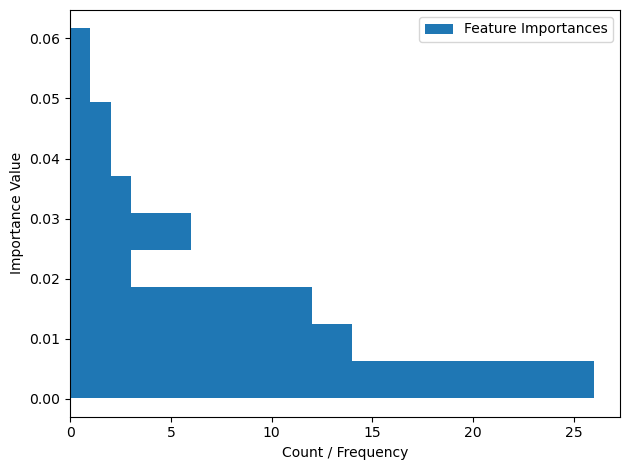

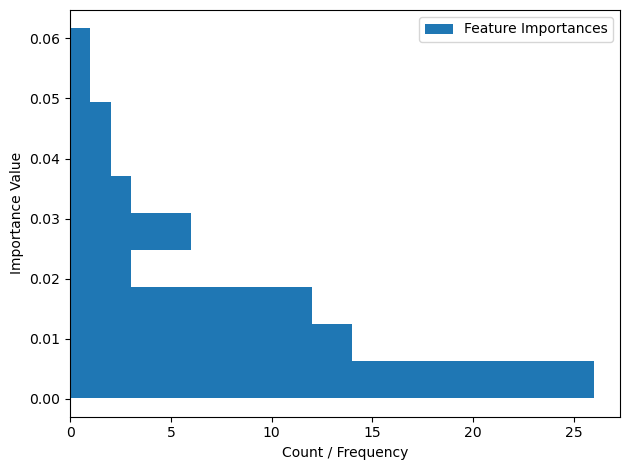

In [17]:
# Extract the physically trained model
trained_model = pipe_3.named_steps["RandomForest"]

displayF_I = feature_importance(trained_model)
displayF_I

### Confusion Matrix (RandomForest)

#### 1. On Test data

In [19]:
y_preds = pipe_3.named_steps["RandomForest"].predict(X_test)
model = pipe_3.named_steps["RandomForest"]



/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


NameError: name 'y' is not defined

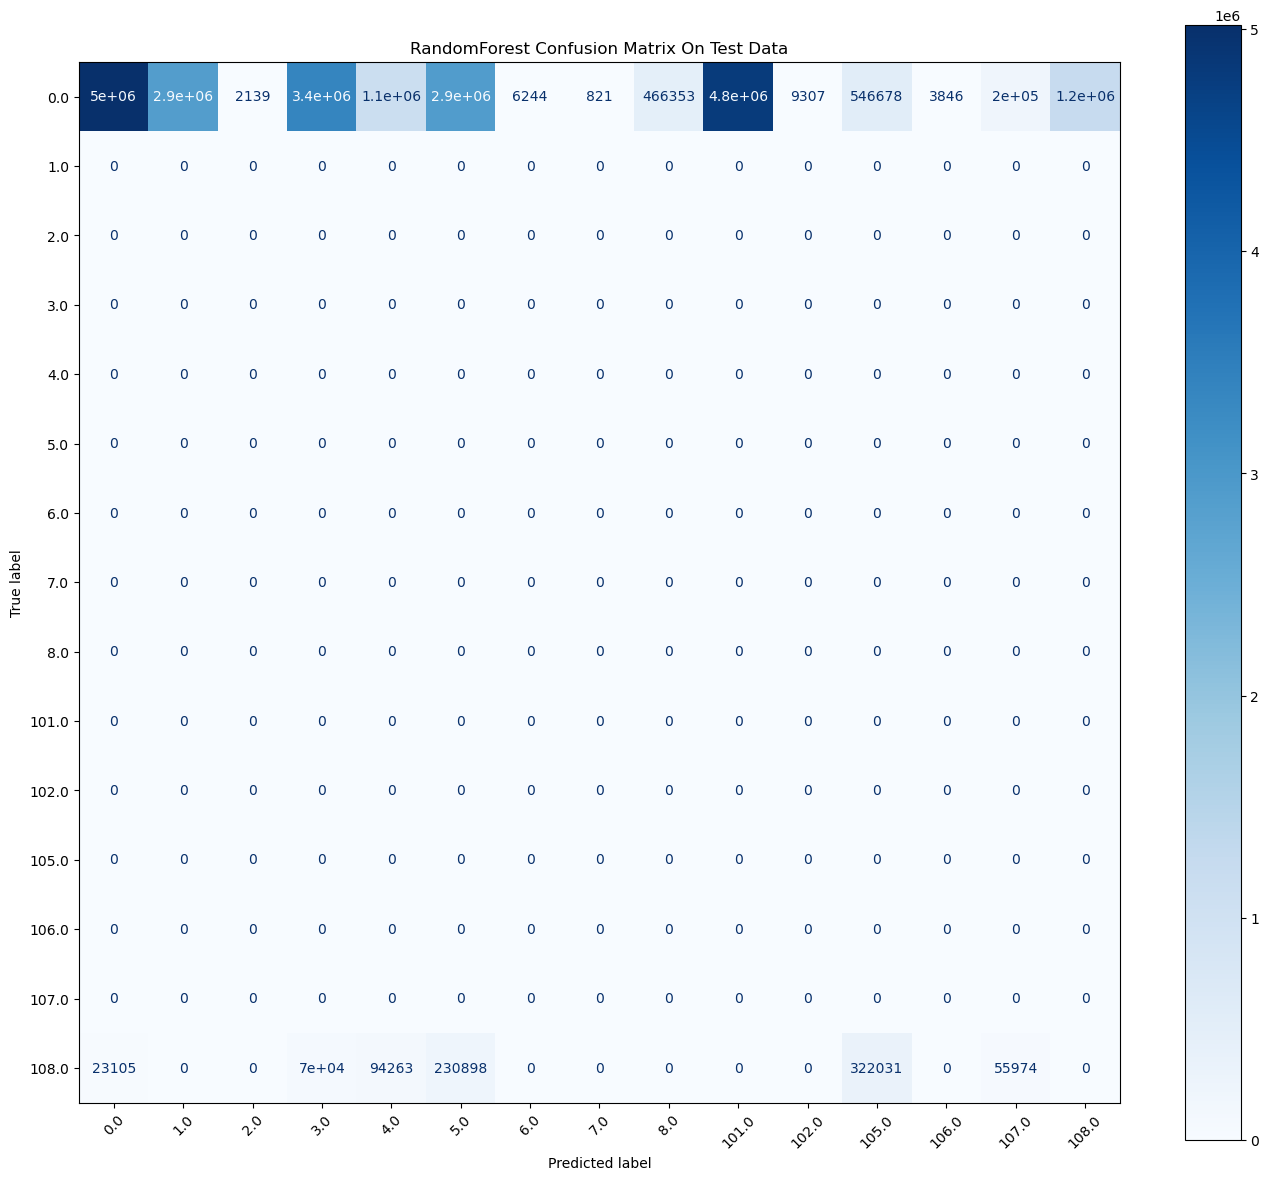

In [21]:
ConfusionMatrix(y_test, y_preds,model=trained_model, model_name="RandomForest")

#### 2. On Train data (to check overfitting)

In [22]:
# 1. Get predicted values on test data
y_preds = pipe_3.named_steps["RandomForest"].predict(X_train)

ConfusionMatrix(y_test, y_preds,model=trained_model, model_name="RandomForest")

/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


ValueError: Found input variables with inconsistent numbers of samples: [20071741, 23332543, 20071741]

### Classification report with Random Forest

In [ ]:
# Creating classification report
report_dict = classification_report(y_test, y_preds, output_dict=True,)

class_report_Random_forest = pd.DataFrame(report_dict).transpose()
class_report_Random_forest.to_csv("../class_report_Random_forest.csv")
class_report_Random_forest

## Model 2: HistGradientBoost

In [10]:
# Split data into X and Y.
X = preprocessed_df.drop(columns="class")
y = preprocessed_df["class"]
group = preprocessed_df["Event_ID"]

In [ ]:
# Instantiate Models
pipe_2 = Pipeline([("Impute", SimpleImputer(strategy="median")),
                   ("RobustScalar", RobustScaler()),
                   ("HistGB", HistGradientBoostingClassifier(class_weight='balanced' ,early_stopping=True ,scoring='recall_macro' ,max_iter = 300,))
                  ])

# Instantiate split class
sgkf = StratifiedGroupKFold(n_splits=3)

# Create a custom scorer that handles the zero division silently
safe_recall_macro = make_scorer(recall_score, average='macro', zero_division=0.0)

# 5. Execute Cross-Validation
print("Starting HistGradBoost cross-validation...")
cv_scores = cross_val_score(
    pipe_2,             
    X,                 
    y,                 
    groups=group,       
    cv=sgkf,            
    scoring=safe_recall_macro,
    n_jobs=1
)

print("===================================")
print(f"Macro Recall Scores: {cv_scores}")
print(f"Average Test Score: {(cv_scores.mean() * 100):.2f}%")

# Final memory cleanup
del X, y, groups
gc.collect()


Starting HistGradBoost cross-validation...


<strong>Classification report with HistGradientBoostClassifier</strong>

In [34]:
# Creating classification report
y_preds_2 = HistGradBoost.predict(X_test)
report_dict = classification_report(y_test, y_preds_2, output_dict=True,)

class_report_2 = pd.DataFrame(report_dict).transpose()
class_report_2.to_csv("../class_report_HistGradBoost.csv")
class_report_2

/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

,precision,recall,f1-score,support
0.0,0.962465,0.756668,0.847248,9.120650e+05
1.0,0.000000,0.000000,0.000000,3.228000e+03
2.0,0.000000,0.000000,0.000000,2.100000e+02
3.0,0.990742,0.775994,0.870317,1.788700e+05
4.0,0.508744,0.900592,0.650194,2.786910e+05
5.0,0.000000,0.000000,0.000000,2.471000e+03
6.0,0.000000,0.000000,0.000000,6.707000e+03
7.0,0.000000,0.000000,0.000000,0.000000e+00
8.0,0.000000,0.000000,0.000000,0.000000e+00
101.0,0.548657,0.449806,0.494338,2.756300e+04


## Observation
RandomForest is not doing too good a job. HistGradientBoostClassfier is performing better. The plan is:

* Tune Hyperparameters of HistGradientBoostClassifier and run RandomizedSearchCv for best params
* Run model with the updated params.
* If model is still not up to 0.9, Importing XGBoost and LighGBM would be the next step.
* If those models still arent enough, Stacking would be employed

Stacking (Stacked Generalization)
Stacking is the evolution of Voting. Instead of just taking a blind average or majority vote of your different models, you train a new meta-model to learn how to best combine their predictions.

In simpler terms: Model 1, 2, and 3 make their predictions. Instead of outputting those, you pass those predictions as the input features to a final Meta-Model (often a simple Logistic Regression). The Meta-Model learns things like: "When Model 1 says 'Cat', it's usually wrong, but when Model 2 says 'Cat', it's usually right, so I will weigh Model 2 heavier."


XGboost, LightGBM and HistGradientBoostClassfier and RandomforestClassifier would be used as the meta-models and will be wrapped around a final LogisticRegression Model

#### Option 1: Tune HistGradientBoostClassifier params

In [53]:
clf_randomcv_score_1 = random_clf_1.score(X_test,y_test)
clf_randomcv_score_1

0.4516392624299427

#### Option 2: Train with XGBoost

In [18]:
# Xgb requires some extra hyperparameter tuning. 
# First, for our imbalanced dataset, compute_sample_weight would be ran to penalize wrongly predicted values on classes with smaller rows like class 7
from sklearn.utils.class_weight import compute_sample_weight


le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

XGB = xgb.XGBClassifier(
    objective='multi:softprob',
    tree_method='hist',
    num_class=15,
    eval_metric='mlogloss'
)

# clf_3.fit(X_train,y_train_encoded, sample_weight=weights)
# clf_score_3 = clf_3.score(X_test,y_test_encoded)
# clf_score_3

In [20]:
pipe_2 = Pipeline([ ("RobustScalar", RobustScaler()), ("xgb", XGB)])
pipe_2.fit(X_train, y_train_encoded, xgb__sample_weight=weights)

test_score = pipe_2.score(X_test,y_test)
print("===============================")
print(f"Accuracy score is {test_score}")

cleared_obj = gc.collect()
print(f"Cleared {cleared_objs} trapped objects from RAM")
del cleared_obj

Accuracy score is 0.8202587063380121
Cleared 3276 trapped objects from RAM


<strong>Classification report with XGBoost</strong>

In [23]:
y_pred_encoded = pipe_2.predict(X_test)
y_preds_3 = le.inverse_transform(y_pred_encoded)

report_dict = classification_report(y_test, y_preds_3, output_dict=True,)

class_report_3 = pd.DataFrame(report_dict).transpose()
class_report_3.to_csv("../class_report_3.csv")
class_report_3

/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

,precision,recall,f1-score,support
0.0,0.882986,0.978851,0.928451,9.120650e+05
1.0,0.000000,0.000000,0.000000,3.228000e+03
2.0,0.000000,0.000000,0.000000,2.100000e+02
3.0,0.982354,1.000000,0.991099,1.788700e+05
4.0,0.964267,0.657574,0.781923,2.786910e+05
5.0,0.000000,0.000000,0.000000,2.471000e+03
6.0,0.691923,0.618160,0.652965,6.707000e+03
101.0,1.000000,0.169067,0.289234,2.756300e+04
102.0,0.950378,0.789246,0.862350,5.096000e+03
105.0,0.979808,0.790686,0.875146,5.486500e+04


<strong>Params tuning on XGBoost</strong>

In [56]:
paramter_list_xgb = {
    'n_estimators': [100, 200, 300, 500],        # XGBoost's version of max_iter
    'max_depth': [3, 5, 7, 9],                   # Tree depth (keep this lower for XGBoost)
    'min_child_weight': [1, 5, 10, 20],          # XGBoost's version of min_samples_leaf
    'subsample': [0.8, 1.0],                     # Randomly sample 80% of rows per tree

}

random_clf_3 = RandomizedSearchCV(
    estimator=clf_3,
    param_distributions=paramter_list_xgb,
    n_iter=30,
    scoring='recall_macro', # Perfect choice for equally important rare faults
    cv=5,
    n_jobs=-1,              # Uses all your CPU cores
    verbose=2,
    random_state=42
)

random_clf_3.fit(X_train_resampled, y_train_encoded)
clf_randomcv_score_3 = random_clf_3.score(X_test,y_test_encoded)
clf_randomcv_score_3

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END max_depth=5, max_iter=500, max_leaf_nodes=50, min_samples_leaf=50; total time= 1.3min
[CV] END max_depth=10, max_iter=200, max_leaf_nodes=50, min_samples_leaf=50; total time=  54.5s
[CV] END max_depth=5, max_iter=100, max_leaf_nodes=31, min_samples_leaf=50; total time= 1.6min
[CV] END max_depth=5, min_child_weight=5, n_estimators=100, subsample=0.8; total time=  49.2s


/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END max_depth=None, max_iter=500, max_leaf_nodes=40, min_samples_leaf=50; total time=  51.4s
[CV] END max_depth=5, max_iter=500, max_leaf_nodes=50, min_samples_leaf=50; total time= 2.0min
[CV] END max_depth=5, max_iter=100, max_leaf_nodes=31, min_samples_leaf=50; total time= 1.4min
[CV] END max_depth=5, min_child_weight=5, n_estimators=100, subsample=0.8; total time=  49.6s
[CV] END max_depth=20, max_iter=400, max_leaf_nodes=25, min_samples_leaf=100; total time=  49.9s
[CV] END max_depth=5, min_child_weight=5, n_estimators=100, subsample=0.8; total time=  48.4s
[CV] END max_depth=3, min_child_weight=10, n_estimators=200, subsample=1.0; total time= 1.3min
[CV] END max_depth=None, max_iter=500, max_leaf_nodes=40, min_samples_leaf=50; total time= 1.5min
[CV] END max_depth=5, max_iter=500, max_leaf_nodes=50, min_samples_leaf=50; total time= 1.2min
[CV] END max_depth=20, max_iter=400, max_leaf_nodes=25, min_samples_leaf=100; total time=  58.9s
[CV] END max_depth=5, min_child_weight=10,

0.5613187282428818

#### Option 3: Training with LightGBM

<strong>Classification report of LightGBM</strong>

In [58]:
# Creating classification report
y_preds_4 = clf_4.predict(X_test)
report_dict = classification_report(y_test, y_preds_4, output_dict=True,)

class_report_4 = pd.DataFrame(report_dict).transpose()
class_report_4.to_csv("../class_report_4.csv")
class_report_4

/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

,precision,recall,f1-score,support
0.0,0.270914,0.355294,0.307419,41180.000000
1.0,0.716367,0.948198,0.816138,34902.000000
2.0,1.000000,0.482759,0.651163,29.000000
3.0,0.993252,0.634912,0.774648,30368.000000
4.0,0.215599,1.000000,0.354721,10363.000000
5.0,0.964584,0.970182,0.967375,136127.000000
6.0,0.977099,0.040913,0.078537,31286.000000
7.0,0.000000,0.000000,0.000000,1005.000000
8.0,0.387097,0.705882,0.500000,17.000000
101.0,0.959281,0.759358,0.847691,54820.000000


####  Option 4: Training with StackingClassifier

In [59]:
# Stacking models using stackclassifier. Logistic regression would be the final model
from sklearn.ensemble import StackingClassifier
from sklearn.preprocessing import StandardScaler

final_estimator = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, C=1.0))
])

clf_stack = StackingClassifier(
    estimators = [
        ("RandomForest", clf_1),
        ("HistGradientBoost",clf_2),
        ("XGBboost",clf_3),
        ("LightGBM",clf_4)
    ],
    final_estimator=final_estimator,
    n_jobs = -1,
    passthrough=False, # Will change this if model scores poorly
    
)
clf_stack.fit(X_train_resampled,y_train_resampled)
clf_score_5 = clf_stack.score(X_test,y_test)
clf_score_5

[CV] END max_depth=9, min_child_weight=5, n_estimators=100, subsample=1.0; total time=  45.7s
[CV] END max_depth=7, min_child_weight=1, n_estimators=500, subsample=0.8; total time= 3.7min
[CV] END max_depth=5, min_child_weight=5, n_estimators=500, subsample=1.0; total time= 3.1min
[CV] END max_depth=7, min_child_weight=5, n_estimators=500, subsample=0.8; total time= 3.4min
[CV] END max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=  44.9s
[CV] END max_depth=5, min_child_weight=5, n_estimators=300, subsample=1.0; total time= 2.1min
[CV] END max_depth=7, min_child_weight=5, n_estimators=500, subsample=0.8; total time= 3.4min
[CV] END max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=  43.9s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.054347 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Tota

0.7392050869593719

<strong>Classification report of StackClassifier</strong>

In [60]:
# Creating classification report
y_preds_5 = clf_stack.predict(X_test)
report_dict = classification_report(y_test, y_preds_5, output_dict=True,)

class_report_5 = pd.DataFrame(report_dict).transpose()
class_report_5.to_csv("../class_report_5.csv")
class_report_5

/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

,precision,recall,f1-score,support
0.0,0.545725,0.369378,0.440560,41180.000000
1.0,0.811149,0.905507,0.855735,34902.000000
2.0,1.000000,0.172414,0.294118,29.000000
3.0,0.982559,0.385867,0.554121,30368.000000
4.0,0.219481,1.000000,0.359958,10363.000000
5.0,0.899368,0.983023,0.939337,136127.000000
6.0,0.989468,0.108099,0.194905,31286.000000
7.0,0.000000,0.000000,0.000000,1005.000000
8.0,0.000000,0.000000,0.000000,17.000000
101.0,0.935374,0.865724,0.899202,54820.000000


In [61]:
model_scores = pd.DataFrame({
    "Random Forest": [clf_score_1],
    "HistGradientBoost": [clf_score_2],
    "HistGradientBoost Randomized": [clf_randomcv_score_1],
    "XGBoost": [clf_score_3],
    "XGBoost Randomized": [clf_randomcv_score_3],
    "LightGBM": [clf_score_4],
    "StackClassifier": [clf_score_5]
})

# Observation :
Well, this is getting frustrating, but that's part of the job. it's never picture perfect. 

In this model, Recall is the most important scoring metrics. Recall aims to see how well the model predicted faults out of all the avaliable faults found. the higher the recall shows my model can spot faults from a mile away. 


From the DataFrame above, we see the various scores of these models. Next steps?

* Use SMOTE (Synthetic Minority Oversampling Technique) : To generate brand new synthetic rows that are plausible combinations of existing ones.

How it works step by step
Take class 7 which has 1,712 rows. SMOTE does this for each existing row:

    1. Pick a row from class 7 — call it point A
    2. Find its K nearest neighbours within class 7 only (default K=5)
    3. Randomly pick one of those neighbours — call it point B
    4. Generate a new synthetic row somewhere along the line between A and B

* Class 0 has some low recalls. Assumption is it is finding it hard to distinguish between transient classes and 0 classes. Notice also the precision of those classes (0 and transient classes) are high. it's most likely grouping all of them and predicting them as each other. A quick DataFrame will be created to really see what it's predicting. Some more feature engineering will be added, like:


    1. Adding a longer STD window. Normal operation is characterised by sensors being consistently stable over a longer period.
    2. Cumulative stability score depicts how many consecutive minutes have all sensors been within their normal range. A long stability           streak strongly signals class 0. A transient class would break this streak.
    3. Adding more training dataset. Add an additional, 10,000 rows.


* Class 3 has an unusually low recall across all models. HistGradientBoosting and Stacking both collapse on class 3. This suggests those models are learning something fundamentally different about class 3 — and since stacking uses HistGradientBoosting as a base model, it inherits this weakness. Flow instability (class 3) has a very distinctive oscillating pattern — the rolling std and sign change features should be capturing this but something is off. We'd have to take a closer look at class 3.

#### Using SMOTE
imbalanced would be used as the library.

In [33]:
pip install -U imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]
Note: you may need to restart the kernel to use updated packages.


#### Feature engineering focusing on class 0


In [32]:
# 60  minute rolling window.
df['P_TPT_std_60'] = df['P-TPT'].rolling(60, min_periods=1).std().bfill()
df['T_TPT_std_60'] = df['T-TPT'].rolling(60, min_periods=1).std().bfill()

# Creating stable Temp and Pressure column
df['all_stable'] = (
    (df['P-TPT'].between(80, 140)) &
    (df['T-TPT'].between(50, 130)) &
    (df['P-MON-CKP'].between(10, 50))
).astype(int)

# Stability streak finding the stabe
df['stability_streak'] = df['all_stable'].groupby( 
    (df['all_stable'] != df['all_stable'].shift()).cumsum()
).cumcount()

'''
This finds the stability of the sensor values. 
it firsts shifts the values of the "all_stable" once, and compares it with the original "all_stable" column 
and adds up the True values cumulatively. Every time a change is detected, the group number increments. 
This creates a unique group ID for each consecutive run. Within each group, 
cumcount() counts how many rows have passed since the group started. Starts at 0:
'''

'\nThis finds the stability of the sensor values. \nit firsts shifts the values of the "all_stable" once, and compares it with the original "all_stable" column \nand adds up the True values cumulatively. Every time a change is detected, the group number increments. \nThis creates a unique group ID for each consecutive run. Within each group, \ncumcount() counts how many rows have passed since the group started. Starts at 0:\n'

In [62]:
model_scores

,Random Forest,HistGradientBoost,HistGradientBoost Randomized,XGBoost,XGBoost Randomized,LightGBM,StackClassifier
0,0.842414,0.669459,0.451639,0.822405,0.561319,0.726402,0.739205


In [63]:
model_scores.to_csv('./model_scores.csv')

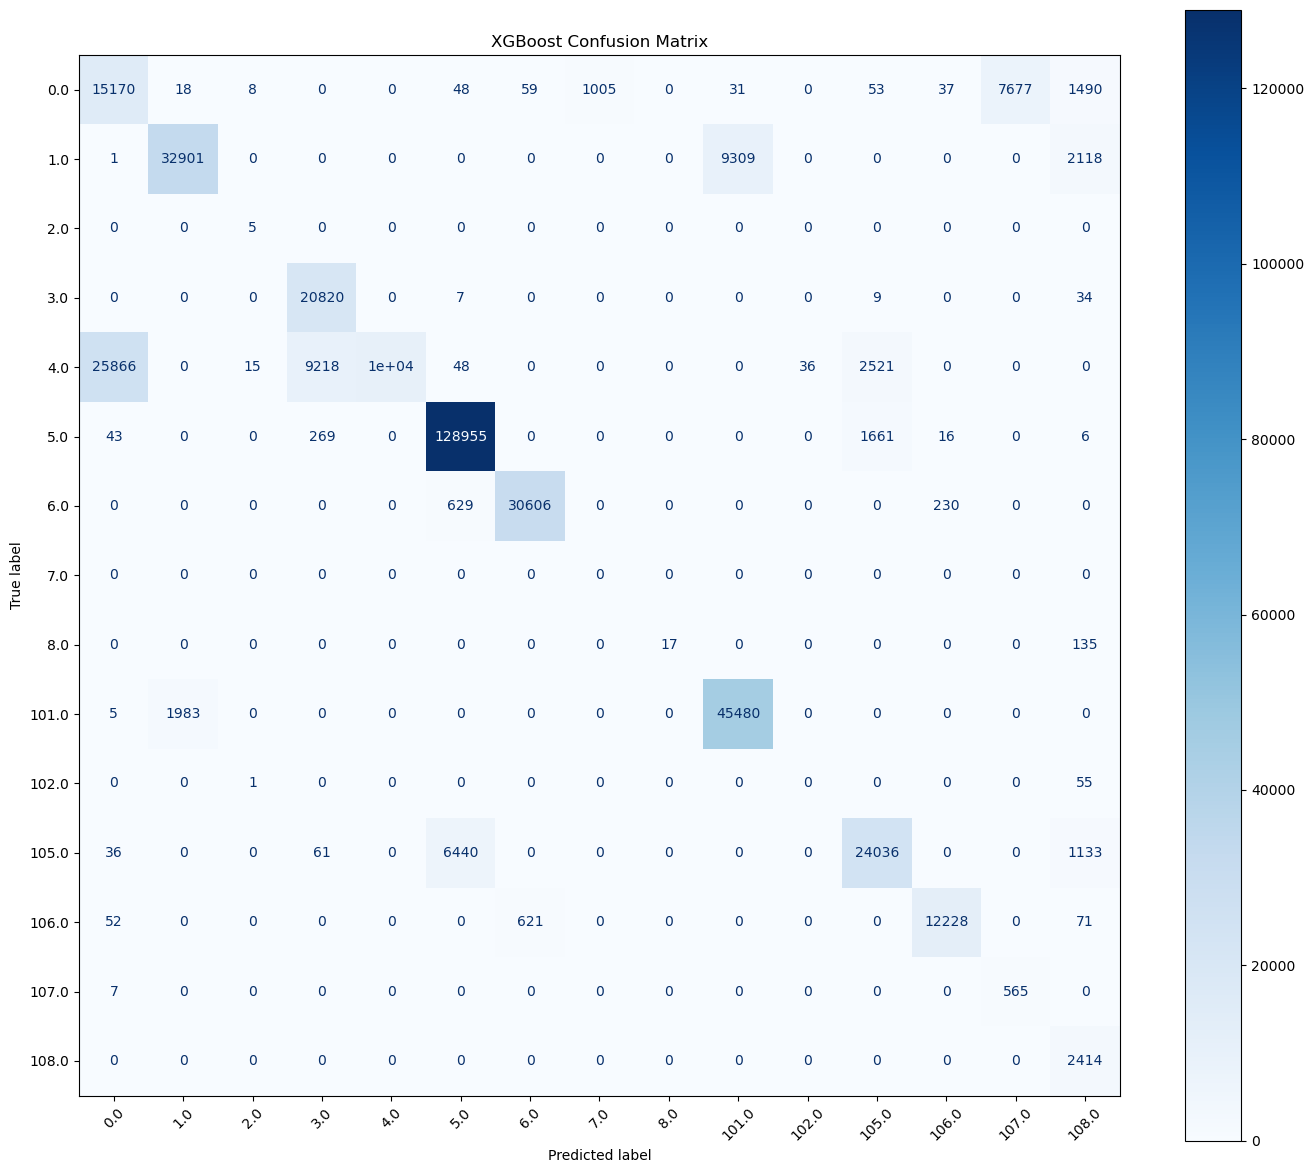

In [66]:
cfm = confusion_matrix(y_pred_encoded, y_test_encoded)
disp = ConfusionMatrixDisplay(confusion_matrix=cfm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(14, 12))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.xticks(rotation=45)
plt.title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_xgb.png', dpi=130, bbox_inches='tight')

## Observation:
Class 7 — Completely invisible to the model
The entire row is zeros. All 1,005 actual class 7 instances are being spread across other classes in numbers too small to even show on this scale. The model has essentially no concept of class 7 existing. This confirms it's a pure data scarcity problem — no amount of tuning will fix it without more real data.
<hr>

Class 0 — Being confused with hydrate classes
Of 41,180 true class 0 rows:

* 7,677 predicted as class 107 (hydrate transient)
* 1,490 predicted as class 108 (hydrate service line)
* 1,005 predicted as class 7 (hydrate production)

Normal operation is being called hydrate in nearly 25% of cases. This is a critical false alarm problem — the stability features we added clearly aren't sufficient to separate normal from hydrate transient.
<hr>

Class 2,7, 102, 107 and 108- These are were most of the error comes from as theyre are being wrongly predicted, these have to be worked and improved. 


### Next steps:
* Extend the rolling window, for each new feature to allow the model to learn patterns over a long duration. maybe 2hrs.
* Produce more samples of 107,7 and 2  (and add 108) using SMOTE. it will be added with BORDERLINESMOTE
* Create a model just for these weak classes and join it with the main model (the model that will be chosen will be the one that performns the best among all models for the class 7, 108, 107 and 2).
* Retune hyperparamters more carefully (use Gridsearchcv and let it run overnight).

Training and scoring will be done at every step.


This will be the final tuning of things and I will choose the best model in terms of recall. 



In [ ]:
# Tuning using GridSearchCv

from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators" : [200,300,500,600,800,1000,1100],
    "max_depth" : [None, 10,20,5,25,30,50],
    "min_samples_leaf" : [2,1,5,4,3],
    "min_samples_split" : [2,3,4,5]
}

grid_clf = GridSearchCV(
    clf_1,
    params,
    scoring="recall_macro",
    n_jobs =-1,
    cv=5,
    verbose=1,
    return_train_score=True
)

grid_clf.fit(X_train_resampled,y_train_resampled)
grid_clf.score(X_test, y_test)

Fitting 5 folds for each of 980 candidates, totalling 4900 fits


/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/Tari/miniconda3/envs/ml_env/lib/python3.14/site-packages/sklearn/utils/parallel

In [ ]:
# Create a special model for weak classes (XGBClassifier first)

# Step 1- create special class list
special_class = [0.0, 7.0, 107.0, 2.0, 108.0]

# Step 2- Create a feature and label for these special classes
mask = df["class"].isin(special_class)
X_special_class  = X_train_resampled[mask]
y_special_class = y_train_resampled[mask]



# Step 3- Train model 
special_model = RandomForestClassifier( 
    n_estimators=300,
    class_weight = "balanced",
    n_jobs = -1
)

specialist_model.fit(X_special_class, y_special_class)







In [ ]:
y_predictions = clf_1.predict_proba(X_test)

uncertain_logic = (y_predictions[:,] > 0.25 | )